In [173]:
# -- import libraries
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.patches import Patch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## This notebook will solely focus on creating the baseline logistic regression model(s)

In [174]:
# -- Read in data
matches_w_stats = pd.read_csv('matches_w_stats_ml.csv')
teams = pd.read_csv('teams.xls')
duals = pd.read_csv('dual_meets.xls')
wrestlers = pd.read_csv('wrestlers_updated.csv')
matches_w_stats

,dual_id,weight_class,event_date,home_wrestler_id,home_name,home_rank,away_wrestler_id,away_name,away_rank,home_win,...,home_std_point_diff,away_matches_wrestled,away_win_rate,away_loss_rate,away_bonus_rate,away_pin_count,away_avg_opponent_rank,away_avg_point_diff,away_avg_points_scored,away_std_point_diff
0,280,141,2025-11-01,267.0,Raymond Adams,160.0,825.0,John Hildebrandt,98.0,False,...,0.000000,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1,281,157,2025-11-01,840.0,Jonathan Ley,46.0,1038.0,Vince Bouzakis,82.0,False,...,0.000000,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
2,281,165,2025-11-01,841.0,Dylan Elmore,34.0,298.0,Dylan Evans,22.0,False,...,0.000000,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
3,281,174,2025-11-01,842.0,Danny Wask,6.0,300.0,Luca Augustine,21.0,True,...,0.000000,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
4,281,184,2025-11-01,1256.0,Daniel Williams,61.0,301.0,Chase Kranitz,38.0,False,...,0.000000,0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5627,547,157,2026-02-23,1448.0,Phil Cuttino,212.0,822.0,Raymond Cmil,205.0,False,...,0.000000,6,0.000000,1.000000,0.000000,0.0,106.500000,-9.800000,1.800000,6.300794
5628,547,174,2026-02-23,399.0,Joshua Roe,237.0,814.0,Beau Lewis,158.0,False,...,3.725289,12,0.166667,0.833333,0.166667,1.0,100.666667,-3.909091,4.636364,7.687061
5629,547,184,2026-02-23,400.0,Reed Douglass,72.0,815.0,Andrew Barford,162.0,True,...,10.122881,11,0.272727,0.727273,0.181818,1.0,111.818182,-6.300000,6.800000,9.499123
5630,547,197,2026-02-23,911.0,Toler Hornick,207.0,816.0,Toby Schoffstall,74.0,False,...,6.976150,8,0.500000,0.500000,0.250000,1.0,98.250000,-2.714286,4.142857,8.400680


## WE NEED TO GET ONE MORE FEATURE FOR EACH WRESTLER, THEIR TEAMS RANK. THIS CAN BE EXTRACTED FROM DUALS AND TEAMS DF

In [175]:
matches_w_stats_copy = matches_w_stats.copy()

In [176]:
duals

,dual_id,team1_id,team1_rank,team1_score,team2_id,team2_rank,team2_score,event_date
0,1,1,14,20,2,20,14,01/10/26
1,2,1,14,22,3,42,16,01/10/26
2,3,3,42,21,4,45,12,01/10/26
3,4,2,20,28,5,50,10,01/10/26
4,5,5,50,23,6,55,15,01/10/26
...,...,...,...,...,...,...,...,...
579,580,50,26,22,33,35,18,02/19/26
580,581,63,47,28,8,75,10,02/19/26
581,582,44,39,37,34,57,3,02/19/26
582,583,54,42,32,60,65,14,02/19/26


In [177]:
# ============================================
# ADD TEAM RANKS TO MATCHES_W_STATS
# ============================================

print("="*60)
print("ADDING TEAM RANKS TO MATCHES")
print("="*60)

# Make a copy
matches_w_stats_copy = matches_w_stats.copy()

# First, we need to get team_id from team_name
# Create team name to team_id mapping
team_name_to_id = dict(zip(teams['name'], teams['team_id']))

# Add team_id columns to matches
matches_w_stats_copy['home_team_id'] = matches_w_stats_copy['home_team_name'].map(team_name_to_id)
matches_w_stats_copy['away_team_id'] = matches_w_stats_copy['away_team_name'].map(team_name_to_id)

print(f"✓ Added team_id columns")

# Now we need to reshape duals to have one row per team per dual
# This will make it easier to join

# Create home team records from duals
duals_home = duals[['dual_id', 'team1_id', 'team1_rank']].copy()
duals_home = duals_home.rename(columns={
    'team1_id': 'team_id',
    'team1_rank': 'team_rank'
})
duals_home['is_home'] = True

# Create away team records from duals
duals_away = duals[['dual_id', 'team2_id', 'team2_rank']].copy()
duals_away = duals_away.rename(columns={
    'team2_id': 'team_id',
    'team2_rank': 'team_rank'
})
duals_away['is_home'] = False

# Combine
duals_long = pd.concat([duals_home, duals_away], ignore_index=True)

print(f"✓ Reshaped duals data: {len(duals_long)} team-dual records")

# Join to get home team rank
matches_w_stats_copy = matches_w_stats_copy.merge(
    duals_long[['dual_id', 'team_id', 'team_rank']].rename(columns={'team_id': 'home_team_id', 'team_rank': 'home_team_rank'}),
    on=['dual_id', 'home_team_id'],
    how='left'
)

# Join to get away team rank
matches_w_stats_copy = matches_w_stats_copy.merge(
    duals_long[['dual_id', 'team_id', 'team_rank']].rename(columns={'team_id': 'away_team_id', 'team_rank': 'away_team_rank'}),
    on=['dual_id', 'away_team_id'],
    how='left'
)

# Check for any missing ranks
missing_home = matches_w_stats_copy['home_team_rank'].isna().sum()
missing_away = matches_w_stats_copy['away_team_rank'].isna().sum()

print(f"\n✓ Added team rank columns")
print(f"  - Home team rank missing: {missing_home} / {len(matches_w_stats_copy)} ({missing_home/len(matches_w_stats_copy)*100:.1f}%)")
print(f"  - Away team rank missing: {missing_away} / {len(matches_w_stats_copy)} ({missing_away/len(matches_w_stats_copy)*100:.1f}%)")

# ============================================
# VERIFY WITH A SAMPLE
# ============================================
print("\n" + "="*60)
print("VERIFICATION SAMPLE")
print("="*60)

# Take a sample of matches
sample = matches_w_stats_copy.sample(5, random_state=42)
print(sample[['dual_id', 'home_team_name', 'home_team_rank', 'away_team_name', 'away_team_rank']].to_string())

# ============================================
# CHECK A SPECIFIC DUAL
# ============================================
print("\n" + "="*60)
print("CHECKING DUAL 280")
print("="*60)

dual_280 = matches_w_stats_copy[matches_w_stats_copy['dual_id'] == 280]
if len(dual_280) > 0:
    print(dual_280[['dual_id', 'home_team_name', 'home_team_rank', 'away_team_name', 'away_team_rank']].head(1))
    
    # Verify in duals
    print("\nCorresponding entry in duals:")
    print(duals[duals['dual_id'] == 280])

# ============================================
# HANDLE MISSING RANKS (if any)
# ============================================
print("\n" + "="*60)
print("HANDLING MISSING RANKS")
print("="*60)

# If there are missing ranks, we can fill with a default value (e.g., 100)
if missing_home > 0 or missing_away > 0:
    print(f"Filling {missing_home + missing_away} missing ranks with default value 100")
    matches_w_stats_copy['home_team_rank'] = matches_w_stats_copy['home_team_rank'].fillna(100)
    matches_w_stats_copy['away_team_rank'] = matches_w_stats_copy['away_team_rank'].fillna(100)
else:
    print("✓ No missing ranks to fill")

# ============================================
# FINAL CHECK
# ============================================
print("\n" + "="*60)
print("FINAL DATAFRAME INFO")
print("="*60)

print(f"Shape: {matches_w_stats_copy.shape}")
print(f"Columns: {matches_w_stats_copy.columns.tolist()}")
print(f"\nHome team rank stats:")
print(matches_w_stats_copy['home_team_rank'].describe())
print(f"\nAway team rank stats:")
print(matches_w_stats_copy['away_team_rank'].describe())

# ============================================
# SAVE
# ============================================
matches_w_stats_copy.to_csv('matches_w_stats_with_team_ranks.csv', index=False)
print("\n✅ Saved matches_w_stats_with_team_ranks.csv")

ADDING TEAM RANKS TO MATCHES
✓ Added team_id columns
✓ Reshaped duals data: 1168 team-dual records

✓ Added team rank columns
  - Home team rank missing: 0 / 5632 (0.0%)
  - Away team rank missing: 0 / 5632 (0.0%)

VERIFICATION SAMPLE
      dual_id home_team_name  home_team_rank      away_team_name  away_team_rank
3728      359        Cornell               9             Harvard              49
1835       96            VMI              75        Sacred Heart              76
3833      430       Bucknell              31          Lock Haven              34
1919       87       Stanford              11  North Dakota State              33
4419      529   Morgan State              77              Lehigh              15

CHECKING DUAL 280
   dual_id home_team_name  home_team_rank away_team_name  away_team_rank
0      280           Duke              72   Sacred Heart              76

Corresponding entry in duals:
     dual_id  team1_id  team1_rank  team1_score  team2_id  team2_rank  \
279      2

## Start with exploratory data analysis

In [178]:
matches = matches_w_stats_copy.copy()

In [179]:
print(f"Columns: {matches.columns}") ; print()
print("="*50, "ML FEATURE Columns Subset", "="*50)

display(matches[["home_win", "weight_class", "home_rank", "away_rank", "home_class", "away_class", 'home_matches_wrestled',
       'home_win_rate', 'home_loss_rate', 'home_bonus_rate', 'home_pin_count',
       'home_avg_opponent_rank', 'home_avg_point_diff',
       'home_avg_points_scored', 'home_std_point_diff',
       'away_matches_wrestled', 'away_win_rate', 'away_loss_rate',
       'away_bonus_rate', 'away_pin_count', 'away_avg_opponent_rank',
       'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff',
       'home_team_id', 'away_team_id', 'home_team_rank', 'away_team_rank']])

print("="*100); print()
print("Numeric Subset")
num_subs = matches[["home_win", "home_rank", "away_rank", 'home_matches_wrestled',
       'home_win_rate', 'home_loss_rate', 'home_bonus_rate', 'home_pin_count',
       'home_avg_opponent_rank', 'home_avg_point_diff',
       'home_avg_points_scored', 'home_std_point_diff',
       'away_matches_wrestled', 'away_win_rate', 'away_loss_rate',
       'away_bonus_rate', 'away_pin_count', 'away_avg_opponent_rank',
       'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff',
       'home_team_id', 'away_team_id', 'home_team_rank', 'away_team_rank']]
display(num_subs.head())

Columns: Index(['dual_id', 'weight_class', 'event_date', 'home_wrestler_id',
       'home_name', 'home_rank', 'away_wrestler_id', 'away_name', 'away_rank',
       'home_win', 'win_type', 'Result', 'home_class', 'home_team_name',
       'away_class', 'away_team_name', 'home_matches_wrestled',
       'home_win_rate', 'home_loss_rate', 'home_bonus_rate', 'home_pin_count',
       'home_avg_opponent_rank', 'home_avg_point_diff',
       'home_avg_points_scored', 'home_std_point_diff',
       'away_matches_wrestled', 'away_win_rate', 'away_loss_rate',
       'away_bonus_rate', 'away_pin_count', 'away_avg_opponent_rank',
       'away_avg_point_diff', 'away_avg_points_scored', 'away_std_point_diff',
       'home_team_id', 'away_team_id', 'home_team_rank', 'away_team_rank'],
      dtype='object')

================================================== ML FEATURE Columns Subset ==================================================


,home_win,weight_class,home_rank,away_rank,home_class,away_class,home_matches_wrestled,home_win_rate,home_loss_rate,home_bonus_rate,...,away_bonus_rate,away_pin_count,away_avg_opponent_rank,away_avg_point_diff,away_avg_points_scored,away_std_point_diff,home_team_id,away_team_id,home_team_rank,away_team_rank
0,False,141,160.0,98.0,JR,JR,0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,24,67,72,76
1,False,157,46.0,82.0,JR,FR,0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,68,27,21,19
2,False,165,34.0,22.0,SO,SO,0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,68,27,21,19
3,True,174,6.0,21.0,JR,SR,0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,68,27,21,19
4,False,184,61.0,38.0,JR,JR,0,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,68,27,21,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5627,False,157,212.0,205.0,FR,JR,1,0.000000,1.000000,0.000000,...,0.000000,0.0,106.500000,-9.800000,1.800000,6.300794,37,66,78,71
5628,False,174,237.0,158.0,SO,FR,12,0.000000,1.000000,0.000000,...,0.166667,1.0,100.666667,-3.909091,4.636364,7.687061,37,66,78,71
5629,True,184,72.0,162.0,JR,FR,11,0.818182,0.181818,0.545455,...,0.181818,1.0,111.818182,-6.300000,6.800000,9.499123,37,66,78,71
5630,False,197,207.0,74.0,SO,JR,4,0.000000,1.000000,0.000000,...,0.250000,1.0,98.250000,-2.714286,4.142857,8.400680,37,66,78,71



Numeric Subset


,home_win,home_rank,away_rank,home_matches_wrestled,home_win_rate,home_loss_rate,home_bonus_rate,home_pin_count,home_avg_opponent_rank,home_avg_point_diff,...,away_bonus_rate,away_pin_count,away_avg_opponent_rank,away_avg_point_diff,away_avg_points_scored,away_std_point_diff,home_team_id,away_team_id,home_team_rank,away_team_rank
0,False,160.0,98.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,24,67,72,76
1,False,46.0,82.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,68,27,21,19
2,False,34.0,22.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,68,27,21,19
3,True,6.0,21.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,68,27,21,19
4,False,61.0,38.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,68,27,21,19


POINT-BISERIAL CORRELATIONS WITH HOME_WIN

Top 10 correlations with home_win:
                  feature  correlation        p_value significant
0               home_rank    -0.475656  5.773904e-316         Yes
1               away_rank     0.412924  7.409762e-231         Yes
2     home_avg_point_diff     0.319342  1.053675e-133         Yes
3           home_win_rate     0.297888  8.890518e-116         Yes
4           away_win_rate    -0.279303  1.922325e-101         Yes
5     away_avg_point_diff    -0.277779  2.576957e-100         Yes
6          home_team_rank    -0.262763   1.383926e-89         Yes
7  away_avg_points_scored    -0.252575   1.079654e-82         Yes
8          home_loss_rate    -0.252032   2.468898e-82         Yes
9  home_avg_points_scored     0.250635   2.047005e-81         Yes


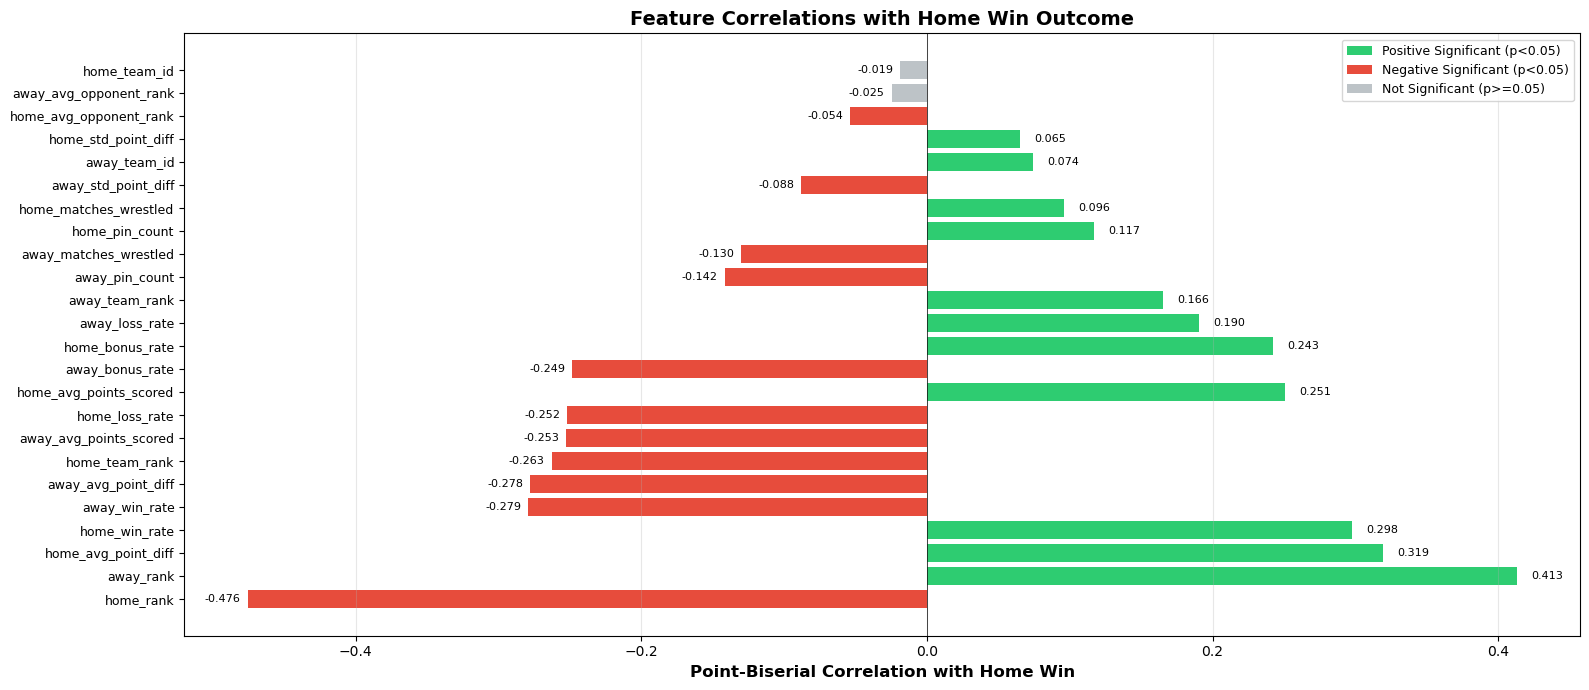


FULL CORRELATION HEATMAP


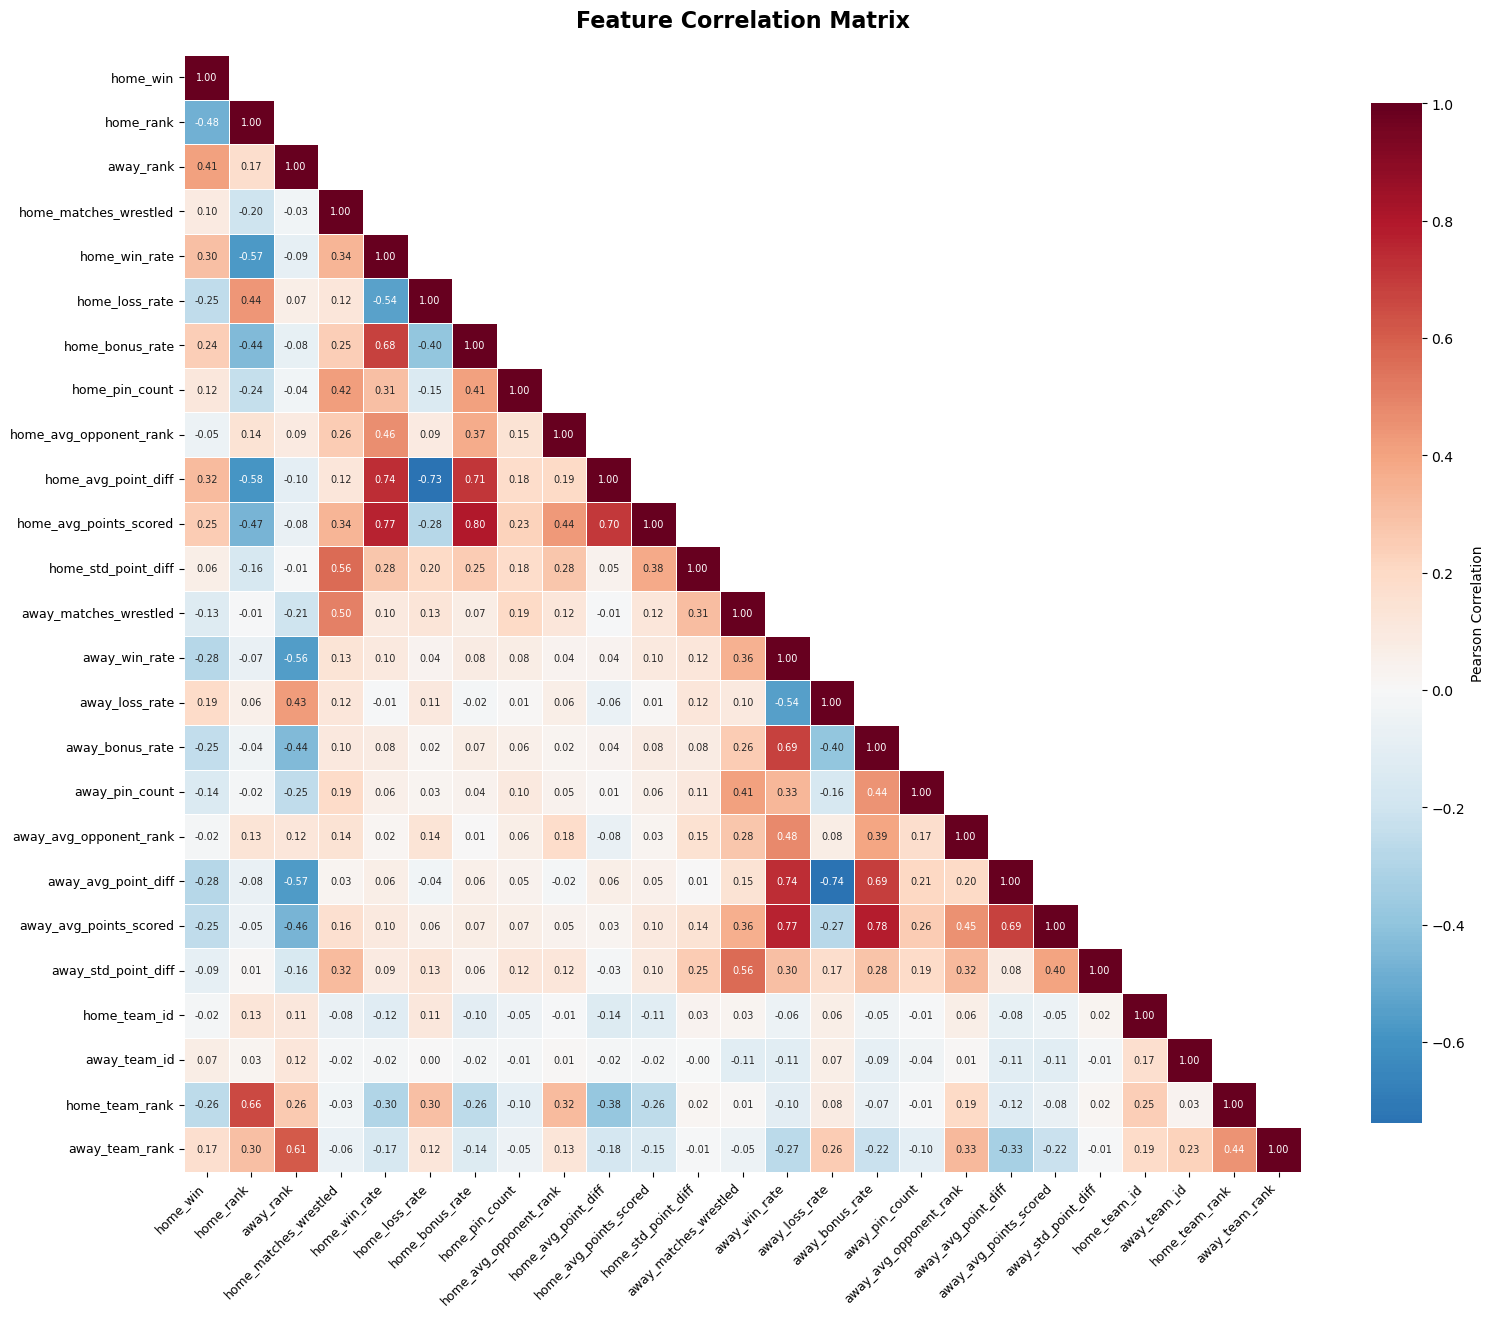


STRONG CORRELATIONS (|r| > 0.7)
           feature1               feature2  correlation
    home_bonus_rate home_avg_points_scored     0.796673
    away_bonus_rate away_avg_points_scored     0.780722
      away_win_rate away_avg_points_scored     0.767259
      home_win_rate home_avg_points_scored     0.766917
      away_win_rate    away_avg_point_diff     0.738518
      home_win_rate    home_avg_point_diff     0.738286
    home_bonus_rate    home_avg_point_diff     0.709870
home_avg_point_diff home_avg_points_scored     0.701993
     home_loss_rate    home_avg_point_diff    -0.732070
     away_loss_rate    away_avg_point_diff    -0.738456

FEATURES RANKED BY CORRELATION WITH HOME_WIN
away_rank                 0.412924
home_avg_point_diff       0.319342
home_win_rate             0.297888
home_avg_points_scored    0.250635
home_bonus_rate           0.242602
away_loss_rate            0.190308
away_team_rank            0.165518
home_pin_count            0.117153
home_matches_wrestled    

In [180]:
# ============================================
# POINT-BISERIAL CORRELATIONS WITH HOME_WIN
# ============================================

print("="*60)
print("POINT-BISERIAL CORRELATIONS WITH HOME_WIN")
print("="*60)

# Get features (excluding home_win)
feature_cols = [col for col in num_subs.columns if col != 'home_win']

# Calculate point-biserial correlations
correlations = []
p_values = []

for col in feature_cols:
    valid_data = num_subs[[col, 'home_win']].dropna()
    if len(valid_data) > 1:
        corr, p_value = pointbiserialr(valid_data['home_win'], valid_data[col])
        correlations.append(corr)
        p_values.append(p_value)
    else:
        correlations.append(np.nan)
        p_values.append(np.nan)

# Create results dataframe
corr_results = pd.DataFrame({
    'feature': feature_cols,
    'correlation': correlations,
    'p_value': p_values,
    'abs_correlation': [abs(c) if not pd.isna(c) else 0 for c in correlations],
    'significant': ['Yes' if p < 0.05 else 'No' if not pd.isna(p) else 'NaN' for p in p_values]
})

# Sort by absolute correlation
corr_results = corr_results.sort_values('abs_correlation', ascending=False).reset_index(drop=True)

print("\nTop 10 correlations with home_win:")
print(corr_results.head(10)[['feature', 'correlation', 'p_value', 'significant']].to_string())

# ============================================
# PLOT 1: POINT-BISERIAL CORRELATIONS BAR CHART
# ============================================

plt.figure(figsize=(16, 7))

# Color bars based on significance and direction
colors = []
for idx, row in corr_results.iterrows():
    if pd.isna(row['p_value']):
        colors.append('gray')
    elif row['p_value'] < 0.05:
        if row['correlation'] > 0:
            colors.append('#2ecc71')  # Green for positive significant
        else:
            colors.append('#e74c3c')  # Red for negative significant
    else:
        colors.append('#bdc3c7')  # Light gray for not significant

bars = plt.barh(range(len(corr_results)), corr_results['correlation'], color=colors)
plt.yticks(range(len(corr_results)), corr_results['feature'], fontsize=9)
plt.xlabel('Point-Biserial Correlation with Home Win', fontsize=12, fontweight='bold')
plt.title('Feature Correlations with Home Win Outcome', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, corr) in enumerate(zip(bars, corr_results['correlation'])):
    if not pd.isna(corr):
        x_pos = bar.get_width()
        if x_pos > 0:
            plt.text(x_pos + 0.01, bar.get_y() + bar.get_height()/2, 
                    f'{corr:.3f}', va='center', fontsize=8)
        else:
            plt.text(x_pos - 0.03, bar.get_y() + bar.get_height()/2, 
                    f'{corr:.3f}', va='center', fontsize=8)

# Add legend
legend_elements = [
    Patch(facecolor='#2ecc71', label='Positive Significant (p<0.05)'),
    Patch(facecolor='#e74c3c', label='Negative Significant (p<0.05)'),
    Patch(facecolor='#bdc3c7', label='Not Significant (p>=0.05)'),
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('pointbiserial_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# PLOT 2: FULL CORRELATION HEATMAP
# ============================================

print("\n" + "="*60)
print("FULL CORRELATION HEATMAP")
print("="*60)

# Calculate correlation matrix
corr_matrix = num_subs.corr()

plt.figure(figsize=(16, 14))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Create heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"},
    annot_kws={"size": 7}
)

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# HIGHLIGHT STRONG CORRELATIONS
# ============================================

print("\n" + "="*60)
print("STRONG CORRELATIONS (|r| > 0.7)")
print("="*60)

# Find pairs with strong correlation
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

strong_corr_df = pd.DataFrame(strong_corr).sort_values('correlation', ascending=False)
if len(strong_corr_df) > 0:
    print(strong_corr_df.to_string(index=False))
else:
    print("No correlations above 0.7")

# ============================================
# CORRELATIONS WITH HOME_WIN (SORTED)
# ============================================

print("\n" + "="*60)
print("FEATURES RANKED BY CORRELATION WITH HOME_WIN")
print("="*60)

home_win_corr = corr_matrix['home_win'].drop('home_win').sort_values(ascending=False)
print(home_win_corr.to_string())

## Our first model will be a baseline logistic regression with only a few features

In [181]:
# -- Playing around with combination of the following
selected_features = [
    'home_rank',
    'away_rank',
    'home_avg_point_diff',
    'home_win_rate',
    'away_win_rate',
    'away_avg_point_diff',
    "home_win",
    "home_avg_points_scored",
    "away_avg_points_scored"
]

# -- Subset
matches_lr = matches[selected_features].copy()
matches_lr['home_win'] = matches_lr['home_win'].astype('int')

# -- Combine features (Home - Away)
matches_lr['rank_diff'] = matches_lr['home_rank'] - matches_lr['away_rank']
matches_lr = matches_lr.drop(columns = ["home_rank", "away_rank"])

matches_lr['point_diff_avg_total'] = matches_lr['home_avg_point_diff'] - matches_lr['away_avg_point_diff']
matches_lr = matches_lr.drop(columns = ["home_avg_point_diff", "away_avg_point_diff"])

matches_lr['win_rate_diff'] = matches_lr['home_win_rate'] - matches_lr['away_win_rate']
matches_lr = matches_lr.drop(columns = ["home_win_rate", "away_win_rate"])


X Train


,rank_diff
4968,-22.0
2162,-155.0
3434,24.0
3845,186.0
202,-54.0
...,...
4394,84.0
2900,-2.0
482,-25.0
169,56.0


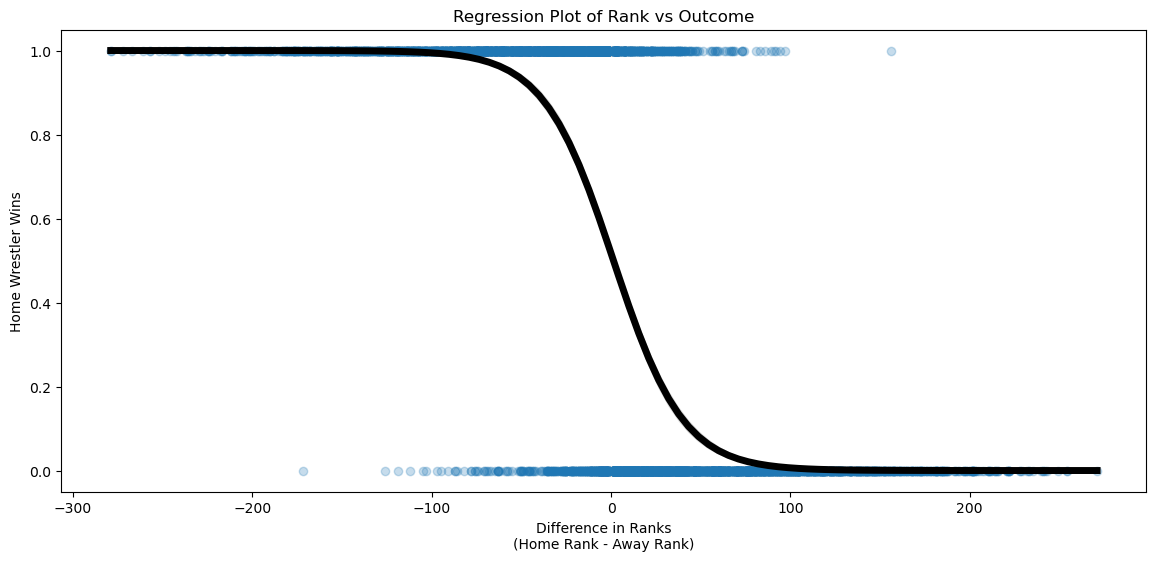

In [182]:
# -- split
X = matches_lr[["rank_diff"]]
y = matches_lr.home_win

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, random_state=42, test_size = .225) ; print()
print("X Train"); display(X_train)

plt.figure(figsize=(14, 6))
sns.regplot(data=matches_lr, x="rank_diff", y="home_win", scatter_kws={"alpha":0.25}, logistic=True, line_kws={'color':'black', 'linewidth':5})
plt.xlabel(f"Difference in Ranks\n(Home Rank - Away Rank)"); plt.ylabel("Home Wrestler Wins"); plt.title("Regression Plot of Rank vs Outcome")
plt.show()

In [168]:
# --  Instantiate model
lr = LogisticRegression()

# -- Fit
lr.fit(X_train, y_train)

# -- Evalutae
print(f"Logistic Regression Training Score: {lr.score(X_train, y_train)}")
print(f"Logistic Regression Testing Score: {lr.score(X_val, y_val)}")

Logistic Regression Training Score: 0.8778643446379468
Logistic Regression Testing Score: 0.8564668769716088


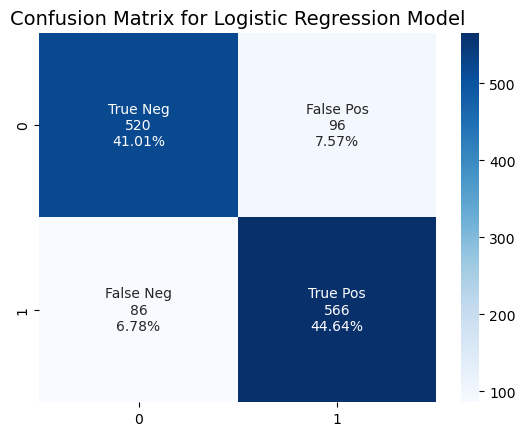

In [169]:
cfm = confusion_matrix(y_val, lr.predict(X_val))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cfm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cfm.flatten()/np.sum(cfm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(cfm.shape)

# Plot
sns.heatmap(cfm, annot=labels, fmt='', cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression Model",fontsize=14)
plt.show()

Train scores: [0.8754716981132076, 0.8730299667036626, 0.8726142920550377, 0.8737239236573457, 0.8703950288504216]
Fold Validation scores: [0.8633540372670807, 0.8731144631765749, 0.8747779751332149, 0.8703374777975134, 0.8836589698046181]
Mean CV Validation score: 0.8730485846358004


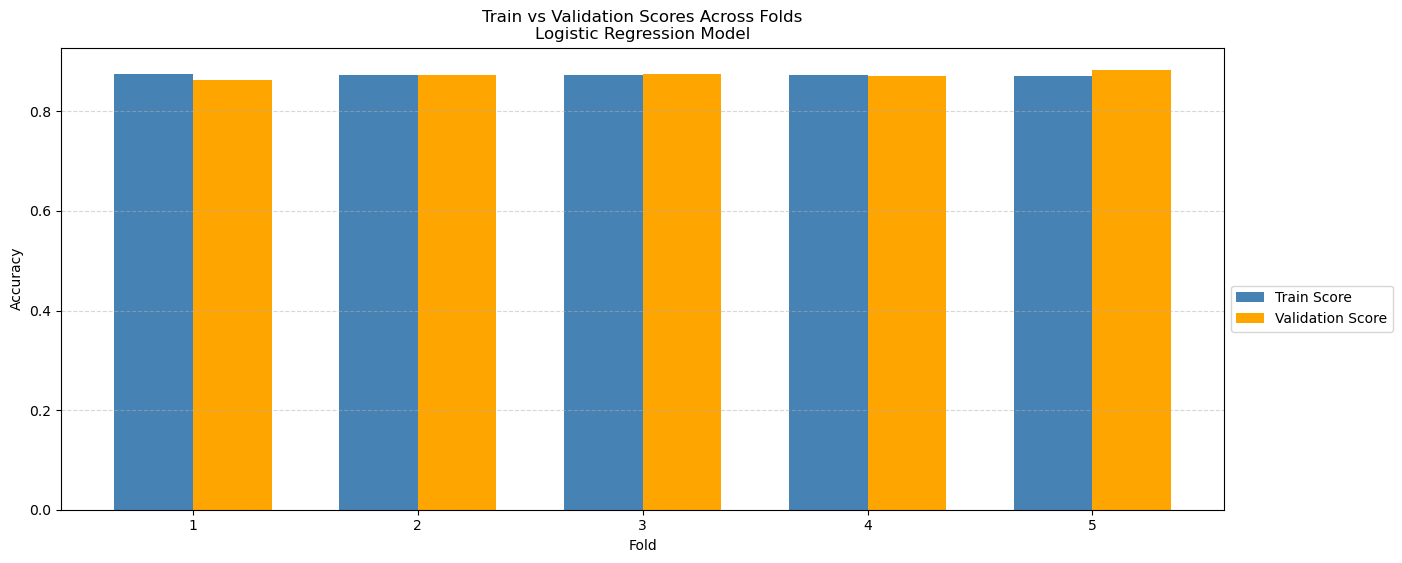

In [170]:
# -- Cross validate model
kf = KFold(n_splits=5, shuffle=True, random_state=42)

val_scores = []
train_scores = []

for train_idx, val_idx in kf.split(X):
    # Split
    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Fit model
    lr.fit(X_train, y_train)

    # Score
    fold_score = lr.score(X_val, y_val)
    train_score = lr.score(X_train, y_train)
    
    val_scores.append(fold_score)
    train_scores.append(train_score)

print("Train scores:", train_scores)
print("Fold Validation scores:", val_scores)
print("Mean CV Validation score:", np.mean(val_scores))

folds = np.arange(1, len(train_scores) + 1)

plt.figure(figsize=(15, 6))
width = 0.35

plt.bar(folds - width/2, train_scores, width=width, label='Train Score', color='steelblue')
plt.bar(folds + width/2, val_scores,   width=width, label='Validation Score', color='orange')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Scores Across Folds\nLogistic Regression Model")
plt.xticks(folds)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [171]:
# -- Save model
import pickle
filename = 'logreg_model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(lr, file)

In [172]:
print(f"Model Coefficient: {lr.coef_}\nIntercept: {lr.intercept_}")

Model Coefficient: [[-0.05073426]]
Intercept: [0.07181408]


# -- Create another model that dosnt use rank columns

In [239]:
# -- new features
new_features = ['home_win_rate', 'away_win_rate', "home_matches_wrestled", "away_matches_wrestled", 'home_win']

matches_sub_new = matches[new_features]
matches_sub_new['win_rate_diff'] = matches_sub_new['home_win_rate'] - matches_sub_new['away_win_rate']

matches_sub_new = matches_sub_new.drop(columns = ["home_win_rate", "away_win_rate"])

matches_sub_new['home_win'] = matches_sub_new['home_win'].astype('int')
matches_sub_new

/tmp/ipykernel_136/3970724821.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches_sub_new['win_rate_diff'] = matches_sub_new['home_win_rate'] - matches_sub_new['away_win_rate']


,home_matches_wrestled,away_matches_wrestled,home_win,win_rate_diff
0,0,0,0,0.000000
1,0,0,0,0.000000
2,0,0,0,0.000000
3,0,0,1,0.000000
4,0,0,0,0.000000
...,...,...,...,...
5627,1,6,0,0.000000
5628,12,12,0,-0.166667
5629,11,11,1,0.545455
5630,4,8,0,-0.500000



X Train


,win_rate_diff
4968,-0.066667
2162,0.527778
3434,0.090909
3845,-0.388889
202,1.000000
...,...
4394,-0.532468
2900,0.272727
482,-0.500000
169,-1.000000


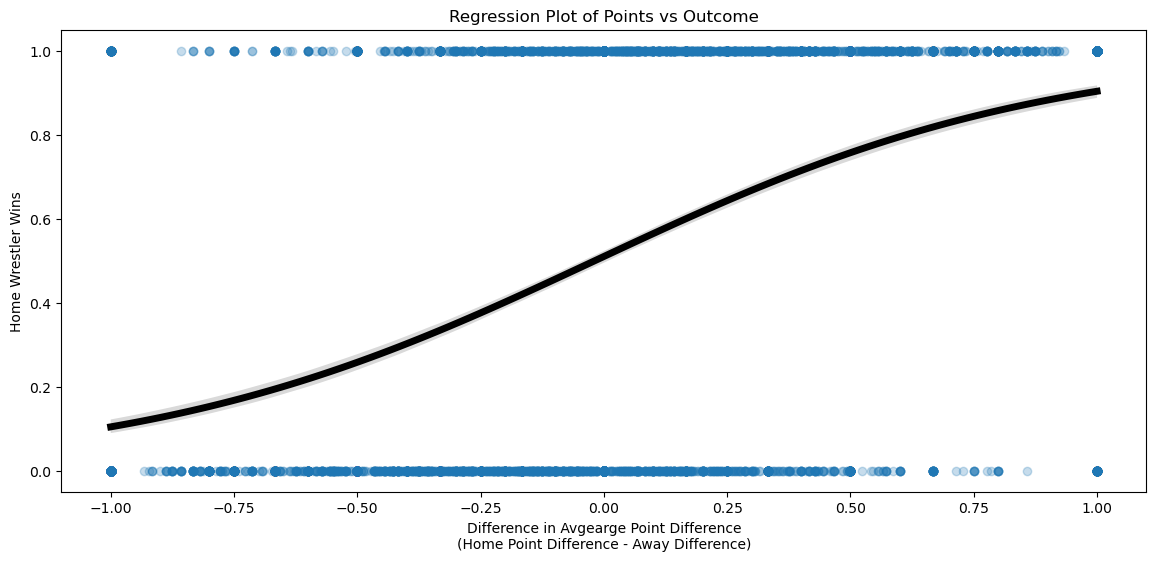

In [240]:
# -- train test split evaluate
X = matches_sub_new[["win_rate_diff"]]
y = matches_sub_new.home_win

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, random_state=42, test_size = .225) ; print()
print("X Train"); display(X_train)

plt.figure(figsize=(14, 6))
sns.regplot(data=matches_sub_new, x="win_rate_diff", y="home_win", scatter_kws={"alpha":0.25}, logistic=True, line_kws={'color':'black', 'linewidth':5})
plt.xlabel(f"Difference in Avgearge Point Difference\n(Home Point Difference - Away Difference)"); plt.ylabel("Home Wrestler Wins"); plt.title("Regression Plot of Points vs Outcome")
plt.show()

In [241]:
# Create the pipeline object
lr = LogisticRegression()

# -- Fit
lr.fit(X_train, y_train)

# -- Evalutae
print(f"Logistic Regression Training Score: {lr.score(X_train, y_train)}")
print(f"Logistic Regression Testing Score: {lr.score(X_val, y_val)}")

Logistic Regression Training Score: 0.6959211732355637
Logistic Regression Testing Score: 0.6821766561514195


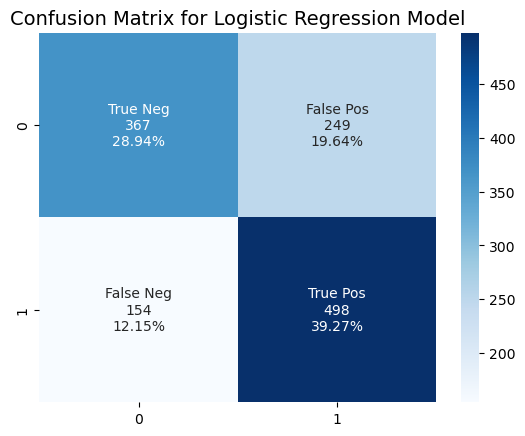

In [242]:
cfm = confusion_matrix(y_val, lr.predict(X_val))

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cfm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cfm.flatten()/np.sum(cfm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(cfm.shape)

# Plot
sns.heatmap(cfm, annot=labels, fmt='', cmap='Blues')
plt.title("Confusion Matrix for Logistic Regression Model",fontsize=14)
plt.show()

Train scores: [0.6996670366259712, 0.6918978912319644, 0.6941855304039058, 0.6906347092765202, 0.687305814469596]
Fold Validation scores: [0.6637089618456078, 0.6938775510204082, 0.6865008880994672, 0.7007104795737122, 0.7131438721136767]
Mean CV Validation score: 0.6915883505305744


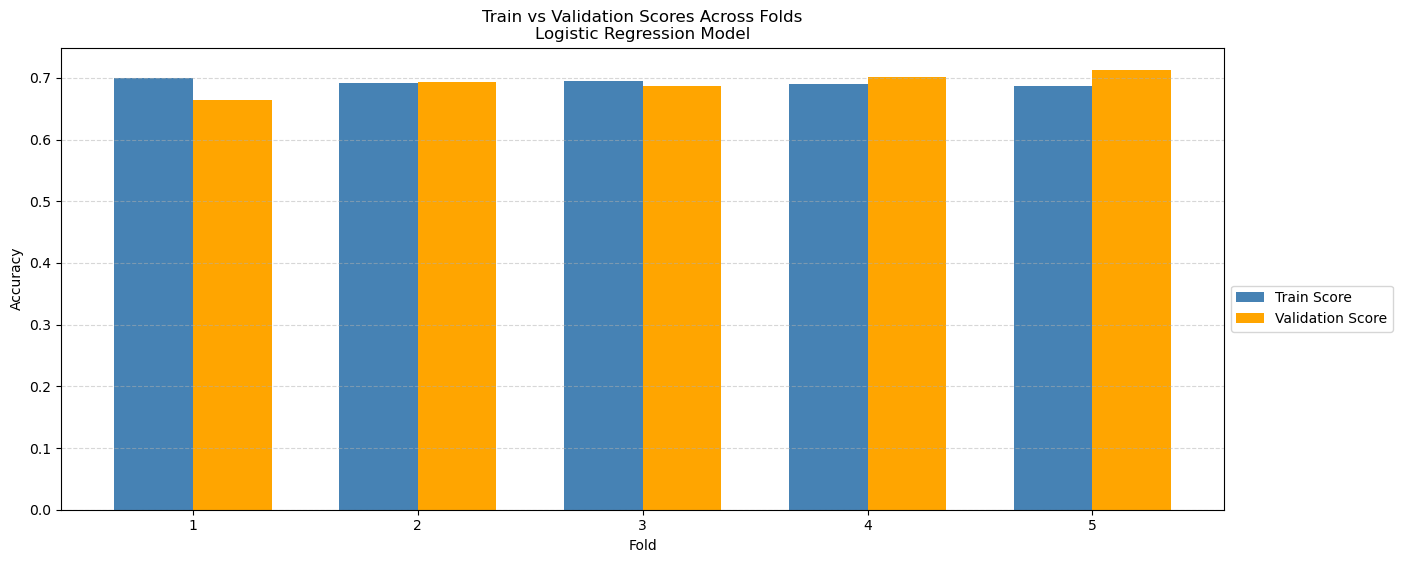

In [243]:
# -- Cross validate model
kf = KFold(n_splits=5, shuffle=True, random_state=42)

val_scores = []
train_scores = []

for train_idx, val_idx in kf.split(X):
    # Split
    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Fit model
    lr.fit(X_train, y_train)

    # Score
    fold_score = lr.score(X_val, y_val)
    train_score = lr.score(X_train, y_train)
    
    val_scores.append(fold_score)
    train_scores.append(train_score)

print("Train scores:", train_scores)
print("Fold Validation scores:", val_scores)
print("Mean CV Validation score:", np.mean(val_scores))

folds = np.arange(1, len(train_scores) + 1)

plt.figure(figsize=(15, 6))
width = 0.35

plt.bar(folds - width/2, train_scores, width=width, label='Train Score', color='steelblue')
plt.bar(folds + width/2, val_scores,   width=width, label='Validation Score', color='orange')

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Scores Across Folds\nLogistic Regression Model")
plt.xticks(folds)
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [244]:
# -- Save model
import pickle
filename = 'logreg_updated_model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(lr, file)

In [245]:
print(f"Model Coefficient: {lr.coef_}\nIntercept: {lr.intercept_}")

Model Coefficient: [[2.13382771]]
Intercept: [0.03440346]
